# Solar Power Forecasting

##### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

In [2]:
plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (12,5)

##### Load Datasets

In [3]:
gen_file = "Plant_1_Generation_Data.csv"
weather_file = "Plant_1_Weather_Sensor_Data.csv"

plant_gen = pd.read_csv(gen_file)
plant_weather = pd.read_csv(weather_file)

print("Generation Data Shape:", plant_gen.shape)
print("Weather Data Shape:", plant_weather.shape)

Generation Data Shape: (68778, 7)
Weather Data Shape: (3182, 6)


##### Convert DATE_TIME to datetime

In [4]:
plant_gen['datetime'] = pd.to_datetime(plant_gen['DATE_TIME'], dayfirst=True)
plant_weather['datetime'] = pd.to_datetime(plant_weather['DATE_TIME'], dayfirst=True)

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_18752\146805977.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  plant_weather['datetime'] = pd.to_datetime(plant_weather['DATE_TIME'], dayfirst=True)


##### Aggregate Generation Data

In [5]:
plant_gen_total = plant_gen.groupby('datetime')['AC_POWER'].sum().reset_index()

##### Aggregate Weather Data

In [6]:
plant_weather_avg = plant_weather.groupby('datetime')[
    ['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']
].mean().reset_index()


##### Merge Generation + Weather

In [7]:
data = pd.merge(plant_gen_total, plant_weather_avg, on='datetime', how='inner')

In [8]:
data.set_index('datetime', inplace=True)

print("\nMerged Data Sample:")
print(data.head())


Merged Data Sample:
                     AC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
datetime                                                                 
2020-05-15 00:00:00       0.0            25.184316           22.857507   
2020-05-15 00:15:00       0.0            25.084589           22.761668   
2020-05-15 00:30:00       0.0            24.935753           22.592306   
2020-05-15 00:45:00       0.0            24.846130           22.360852   
2020-05-15 01:00:00       0.0            24.621525           22.165423   

                     IRRADIATION  
datetime                          
2020-05-15 00:00:00          0.0  
2020-05-15 00:15:00          0.0  
2020-05-15 00:30:00          0.0  
2020-05-15 00:45:00          0.0  
2020-05-15 01:00:00          0.0  


##### Resample to Daily Data

In [9]:
daily_data = data.resample('D').agg({
    'AC_POWER':'sum',
    'AMBIENT_TEMPERATURE':'mean',
    'MODULE_TEMPERATURE':'mean',
    'IRRADIATION':'mean'
})

print("\nDaily Data Sample:")
print(daily_data.head())


Daily Data Sample:
                 AC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
datetime                                                             
2020-05-15  550830.959402            27.430823           32.582964   
2020-05-16  568359.821428            26.780538           31.858851   
2020-05-17  660975.389285            26.686727           32.740435   
2020-05-18  470969.708929            23.850938           27.814344   
2020-05-19  532250.491070            25.338021           29.725163   

            IRRADIATION  
datetime                 
2020-05-15     0.204699  
2020-05-16     0.211951  
2020-05-17     0.238869  
2020-05-18     0.159026  
2020-05-19     0.194031  


##### Exploratory Analysis

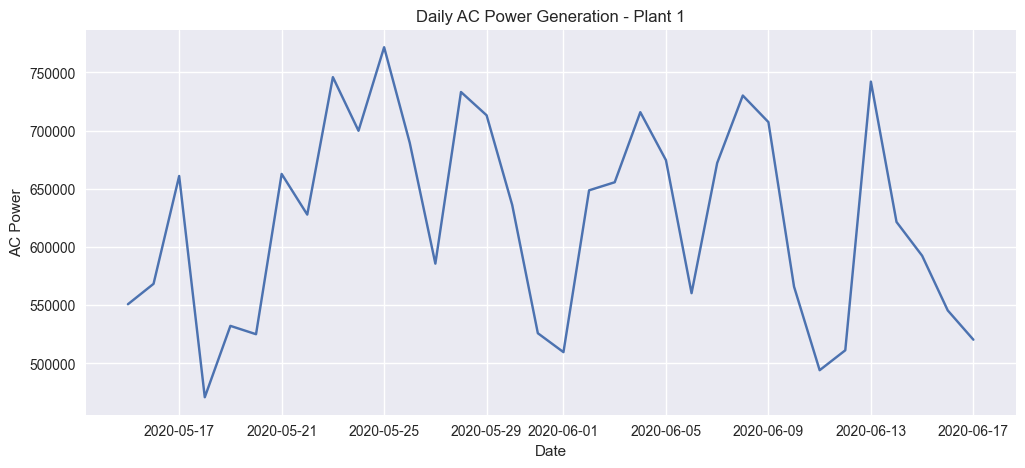

In [10]:
plt.plot(daily_data['AC_POWER'])
plt.title("Daily AC Power Generation - Plant 1")
plt.xlabel("Date")
plt.ylabel("AC Power")
plt.show()

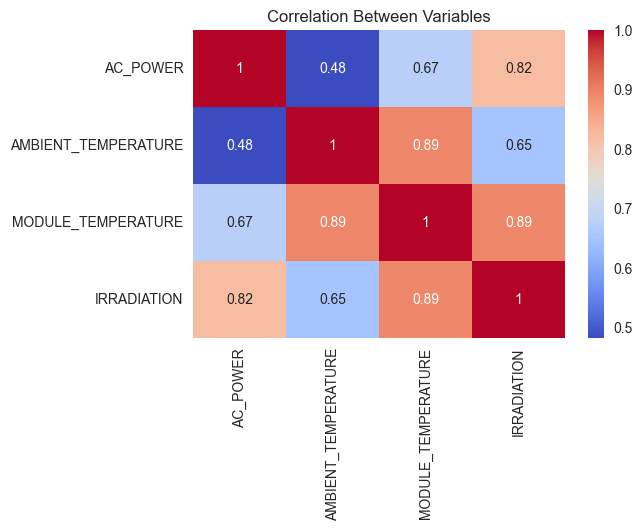

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(daily_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Variables")
plt.show()

##### Check Stationarity

In [12]:
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("Series is Stationary")
    else:
        print("Series is NOT Stationary")

print("\nADF Test on AC_POWER:")
adf_test(daily_data['AC_POWER'])


ADF Test on AC_POWER:
ADF Statistic: -3.489501124070394
p-value: 0.008260857015114576
Series is Stationary


##### Seasonal Decomposition

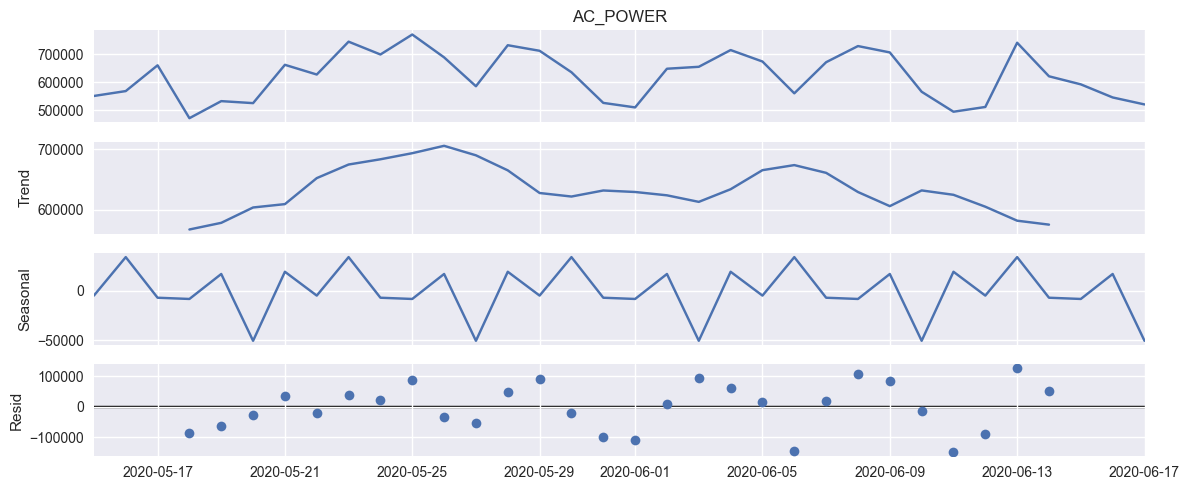

In [13]:
decompose = seasonal_decompose(daily_data['AC_POWER'], model='additive', period=7)
decompose.plot()
plt.show()

##### Train-Test Split

In [14]:
train = daily_data.iloc[:-7]
test = daily_data.iloc[-7:]

y_train = train['AC_POWER']
X_train = train[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']]

y_test = test['AC_POWER']
X_test = test[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']]

##### Fit SARIMAX Model

In [15]:
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

results = model.fit(disp=False)
print(results.summary())

c:\Users\USER-PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                     
Dep. Variable:                          AC_POWER   No. Observations:                   27
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -233.311
Date:                           Fri, 27 Feb 2026   AIC                            482.621
Time:                                   17:02:11   BIC                            490.177
Sample:                               05-15-2020   HQIC                           483.900
                                    - 06-10-2020                                         
Covariance Type:                             opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
AMBIENT_TEMPERATURE  7.358e+04   5.75e+04      1.279      0.201   -3.92e+04    1.86e+05
MODULE_TEMPERATU

##### Forecast on Test Data

In [16]:
forecast = results.get_forecast(steps=len(test), exog=X_test)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

##### Evaluate Model

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
print("\nRMSE:", rmse)


RMSE: 20990.9439222099


##### Plot Forecast vs Actual

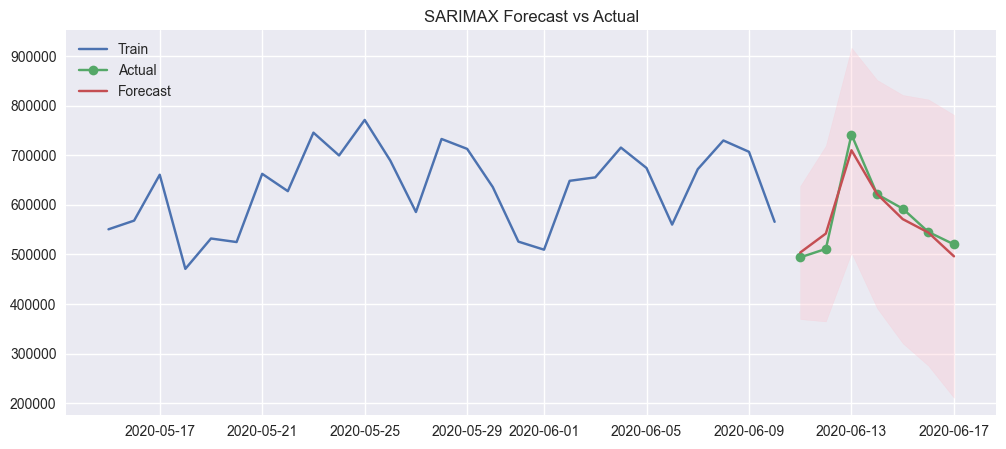

In [18]:
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Actual', marker='o')
plt.plot(forecast_mean, label='Forecast', marker='x')
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color='pink', alpha=0.3
)
plt.title("SARIMAX Forecast vs Actual")
plt.legend()
plt.show()


##### Forecast Next 7 Days

In [19]:
future_forecast = results.get_forecast(steps=7, exog=X_test)
future_values = future_forecast.predicted_mean

print("\nNext 7 Days Forecast:")
print(future_values)


Next 7 Days Forecast:
2020-06-11    503949.823492
2020-06-12    542247.571178
2020-06-13    710343.669517
2020-06-14    621872.374869
2020-06-15    571411.059743
2020-06-16    544256.725626
2020-06-17    496291.025277
Freq: D, Name: predicted_mean, dtype: float64
